In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 30.2 MB/s eta 0:00:00


# Cấu trúc file dataset
### dataset/
### ├─ train/
### │  ├─ images/
### │  │  ├─ img_001.jpg
### │  │  ├─ img_002.jpg
### │  │  └─ ...
### │  └─ labels/
### │     ├─ img_001.txt
### │     ├─ img_002.txt
### │     └─ ...
### │
### ├─ valid/
### │  ├─ images/
### │  └─ labels/
### │
### ├─ test/
### │  ├─ images/
### │  └─ labels/
### │
### └─ data.yaml

# Nội dung file data.yaml:
##  path: ../data
##  train: data/images/train
##  val: data/images/val

# số classes
##  nc: 3

# tên các class
##  names: ['car', 'motorbike', 'truck']

# B1: Gửi dataset lên hệ thống dưới dạng file zip và giải nén (chỉ sử dụng khi chạy trên jupyter website)

In [ ]:
import zipfile
import os

from google.colab import files
uploaded = files.upload()

with zipfile.ZipFile("containerCode_data_ver01.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset")

Saving containerCode_data_ver01.zip to containerCode_data_ver01.zip


In [ ]:
uploaded = files.upload()

Saving last.pt to last.pt


# B2: Chạy huấn luyện model ngầm để theo dõi quá trình huấn luyện (chỉ chạy chung với B4 nếu muốn theo dõi thời gian thực kết quả huấn luyện)

In [ ]:
# -- Trainning model ở nền kết hợp vẽ đồ thị

import subprocess

# Lệnh huấn luyện YOLOv8
command = [
    "yolo",
    "task=detect",
    "mode=train",
    "model=yolov8s.pt",
    "data=dataset/data.yaml",
    "epochs=50",
    "imgsz=768",
    "batch=8",
    "project=results",
    "name=AI_MODEL",
    "exist_ok=True",
    "patience=7",
    "save=True",
    "lr0=0.001",
    "cos_lr=True",
    "warmup_epochs=3",
    "val=True",
    "augment=True",
    "hsv_h=0.015",
    "hsv_s=0.6",
    "hsv_v=0.4",
    "fliplr=0.5",
    "translate=0.1",
    "scale=0.3",
    "mosaic=1.0",
    "mixup=0.2",
    "degrees=5",
    "shear=2",
    "verbose=True"
]

# Chạy huấn luyện YOLO dưới nền bằng subprocess
process = subprocess.Popen([" ".join(command)], shell=True)
print("Huấn luyện đã được khởi chạy ở nền.")

Huấn luyện đã được khởi chạy ở nền.


# B3: Huấn luyện model AI detect dữ liệu (Chỉ chạy B2 hoặc B3 để huấn luyện model AI)

In [ ]:
from ultralytics import YOLO
import os

# Cấu hình dataset container bằng file YAML
YAML_PATH = "dataset/containerCode_data_ver01/data.yaml"
if not os.path.exists(YAML_PATH):
    raise FileNotFoundError(f"Không tìm thấy file: {YAML_PATH}")

# Chọn model YOLOv8 để huấn luyện
# Nếu muốn huấn luyện tiếp từ model trước đó thì sử dụng file last.pt
model_version = "yolov8s.pt"

# Load model
model = YOLO(model_version)

# Huấn luyện với cấu hình tối ưu cho 12GB RAM
model.train(
    data=YAML_PATH,
    epochs=100,
    imgsz=640,            # giảm size ảnh để tiết kiệm RAM
    batch=6,              # giảm batch để tránh OOM
    project="results",
    name="AI_MODEL",
    exist_ok=True,

    patience=8,
    save=True,
    lr0=0.001,
    cos_lr=True,
    warmup_epochs=3,
    val=True,

    augment=True,
    hsv_h=0.01,
    hsv_s=0.5,
    hsv_v=0.3,
    fliplr=0.3,
    translate=0.1,
    scale=0.2,
    mosaic=0.5,           # giảm mosaic để tránh ảnh to bất thường
    mixup=0.0,            # tắt mixup để tiết kiệm RAM
    degrees=1,
    shear=0.5,

    verbose=True
)

print("Training complete!")

Ultralytics 8.3.196 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=randaugment, batch=6, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=dataset/containerCode_data_ver01/data.yaml, degrees=1, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.3, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.01, hsv_s=0.5, hsv_v=0.3, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=last.pt, momentum=0.937, mosaic=0.5, multi_scale=False, name=AI_MODEL, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=8, perspective=0.0, plots=True,

# B4: Vẽ biểu đồ quá trình huấn luyện AI (Sử dụng chung với B2 để theo dõi kết quả huấn luyện thời gian thực, sử dụng sau khi huấn luyện xong B3 để xem kết quả huấn luyện tổng hợp)

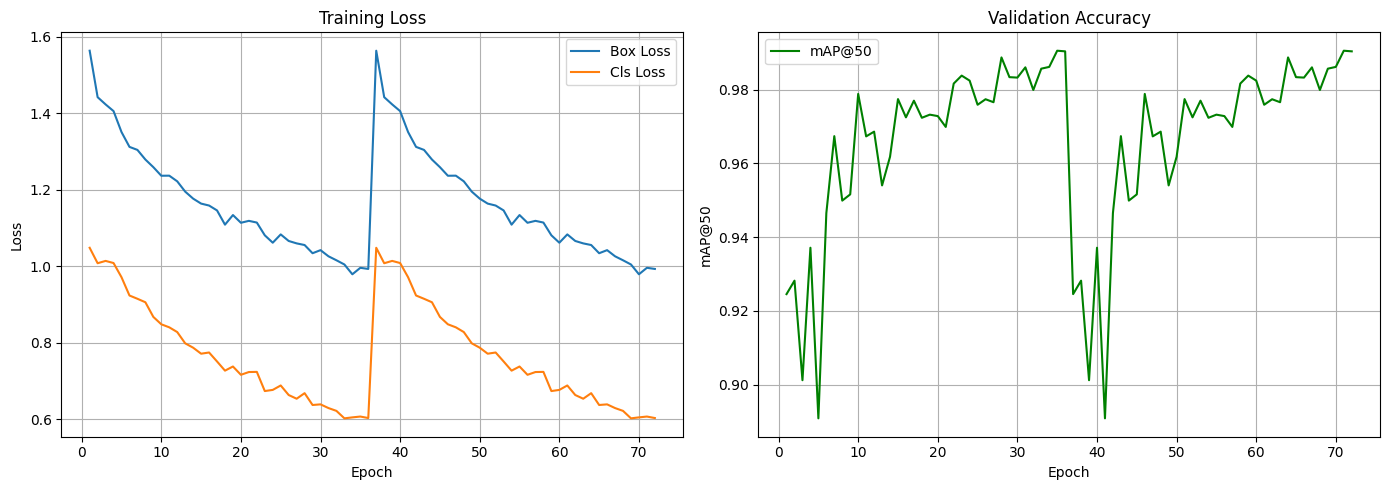

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import time
from IPython.display import clear_output
import os



log_path = 'results/AI_MODEL/results.csv'
last_epoch = -1

print("Bắt đầu theo dõi quá trình huấn luyện...")

while True:
    if not os.path.exists(log_path):
        print("Chưa thấy file log. Chờ 20 giây rồi thử lại...")
        time.sleep(20)
        continue

    try:
        df = pd.read_csv(log_path)
    except Exception as e:
        print("Lỗi khi đọc log:", e)
        time.sleep(10)
        continue

    if len(df) == 0 or df.index[-1] == last_epoch:
        time.sleep(10)
        continue

    last_epoch = df.index[-1]

    # Tạo cột epoch từ index (nếu chưa có sẵn)
    df['epoch'] = df.index + 1

    # === Phân tích các chỉ số ===
    box_loss = df['train/box_loss']
    cls_loss = df['train/cls_loss']
    map50 = df['metrics/mAP50(B)']
    epochs = df['epoch']

    clear_output(wait=True)
    print(f"Epoch hiện tại: {last_epoch + 1} / {df['epoch'].max()}")
    print(f"Box Loss mới nhất: {box_loss.iloc[-1]:.4f}")
    print(f"mAP@50 mới nhất: {map50.iloc[-1]:.4f}")

    # === Kiểm tra overfitting hoặc giảm chất lượng ===
    if len(map50) > 3:
        if map50.iloc[-1] < map50.iloc[-2] < map50.iloc[-3]:
            print("[WARNING] Cảnh báo: mAP@50 đang giảm liên tiếp → mô hình có thể bị overfitting.")
        if box_loss.iloc[-1] > box_loss.min() * 1.5:
            print("[WARNING] Cảnh báo: Box loss tăng cao → kiểm tra learning rate hoặc augment.")

    # === Vẽ biểu đồ ===
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, box_loss, label='Box Loss')
    plt.plot(epochs, cls_loss, label='Cls Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Loss")
    plt.grid(True)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, map50, label='mAP@50', color='green')
    plt.xlabel("Epoch")
    plt.ylabel("mAP@50")
    plt.title("Validation Accuracy")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

    time.sleep(10)  # cập nhật mỗi 30 giây
